## Plot for kernel test

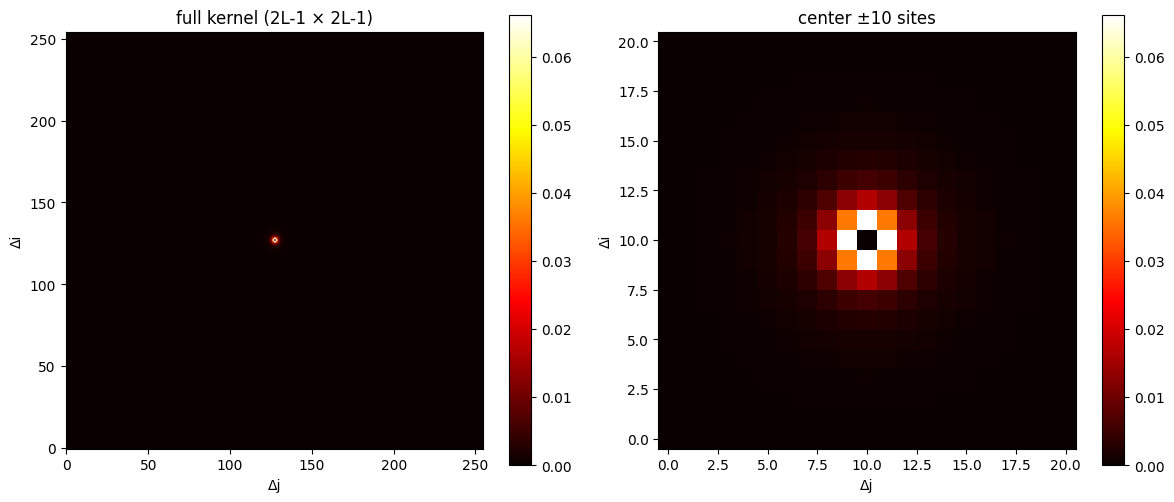

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, "..")  # so imports from src/ work from inside analysis/

from src.kernel import build_kernel

L = 128
r0=1.0
K = build_kernel(L, r0=r0, epsilon_dissipation=0.01)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# full kernel footprint
im0 = axes[0].imshow(K, cmap="hot", origin="lower")
axes[0].set_title("full kernel (2L-1 × 2L-1)")
axes[0].set_xlabel("Δj"); axes[0].set_ylabel("Δi")
plt.colorbar(im0, ax=axes[0])

# zoom into the center (±10 sites) to see the regularization
c = L - 1  # center index
w = 10
im1 = axes[1].imshow(K[c-w:c+w+1, c-w:c+w+1], cmap="hot", origin="lower")
axes[1].set_title(f"center ±{w} sites")
axes[1].set_xlabel("Δj"); axes[1].set_ylabel("Δi")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

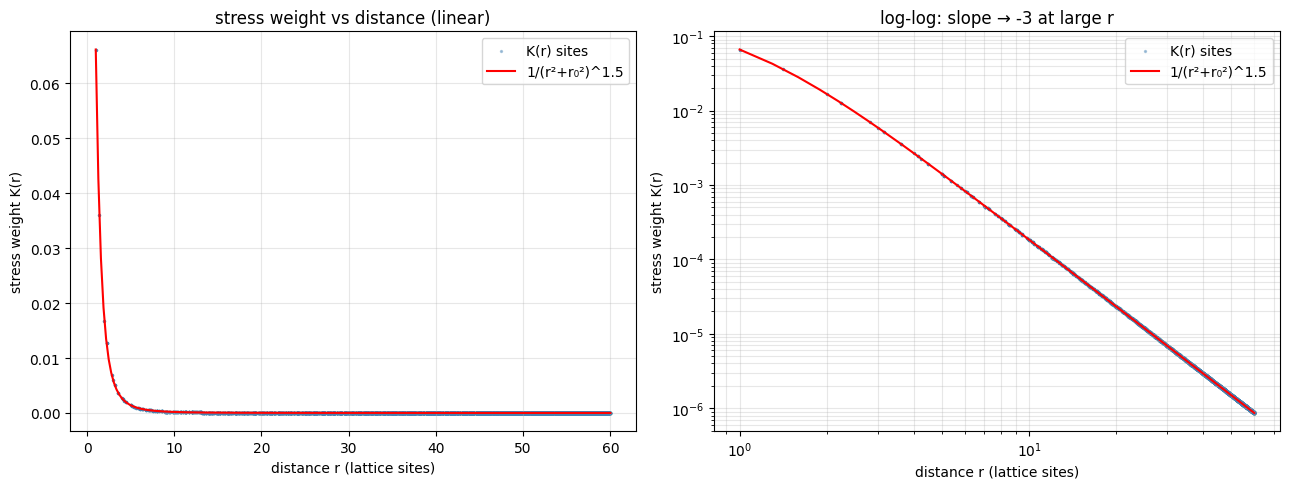

In [5]:
c = L - 1
max_r = 60
rs, ks = [], []

for di in range(-max_r, max_r + 1):
    for dj in range(-max_r, max_r + 1):
        r = np.sqrt(di**2 + dj**2)
        if 0 < r <= max_r:
            rs.append(r)
            ks.append(K[c + di, c + dj])

rs = np.array(rs)
ks = np.array(ks)

# theoretical 1/r^3 line for comparison
r_theory = np.linspace(1, max_r, 200)
k_theory = ks[np.argmin(np.abs(rs - 1))] * (1 + r0**2) ** 1.5 / (r_theory**2 + r0**2) ** 1.5

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# scatter: every site's actual weight vs its distance
axes[0].scatter(rs, ks, s=2, alpha=0.4, color="steelblue", label="K(r) sites")
axes[0].plot(r_theory, k_theory, "r-", linewidth=1.5, label="1/(r²+r₀²)^1.5")
axes[0].set_xlabel("distance r (lattice sites)")
axes[0].set_ylabel("stress weight K(r)")
axes[0].set_title("stress weight vs distance (linear)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# same on log-log: should be a straight line at large r confirming 1/r^3
axes[1].scatter(rs, ks, s=2, alpha=0.4, color="steelblue", label="K(r) sites")
axes[1].plot(r_theory, k_theory, "r-", linewidth=1.5, label="1/(r²+r₀²)^1.5")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("distance r (lattice sites)")
axes[1].set_ylabel("stress weight K(r)")
axes[1].set_title("log-log: slope → -3 at large r")
axes[1].legend()
axes[1].grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()


## Heterogeneity test

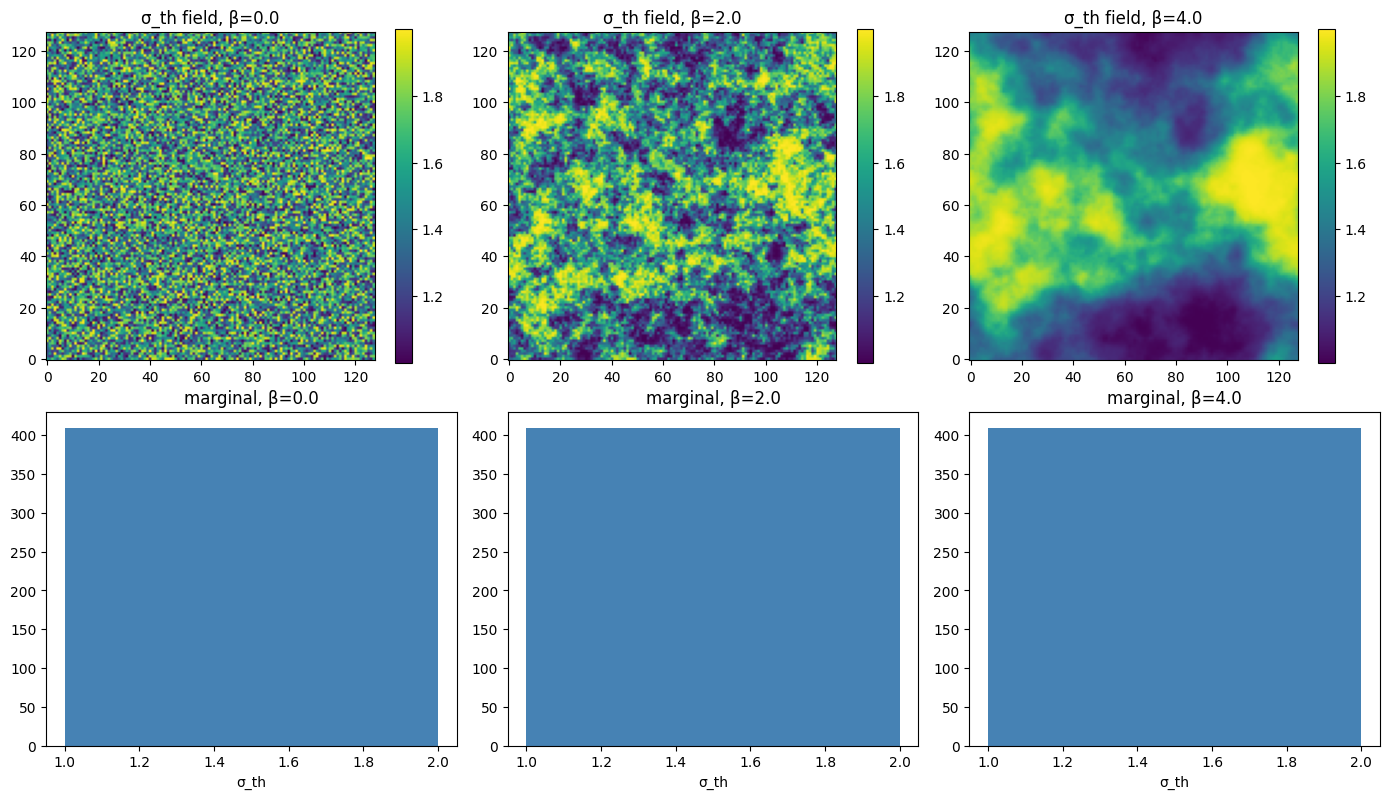

In [6]:
from dataclasses import replace
from src.config import load_config
from src.heterogeneity import threshold_field, residual_field

cfg = load_config("../experiments/params.yaml")

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for col, beta in enumerate([0.0, 2.0, 4.0]):
    c = replace(cfg, beta=beta)              # frozen config -> make a modified copy
    sth = threshold_field(c, np.random.default_rng(0))

    im = axes[0, col].imshow(sth, cmap="viridis", origin="lower")
    axes[0, col].set_title(f"σ_th field, β={beta}")
    plt.colorbar(im, ax=axes[0, col])

    axes[1, col].hist(sth.ravel(), bins=40, color="steelblue")
    axes[1, col].set_title(f"marginal, β={beta}")
    axes[1, col].set_xlabel("σ_th")

plt.tight_layout()
plt.show()